# Missing Value Identification

# About Dataset
The Titanic dataset contains information about **891 passengers and 12 columns** who travelled on the RMS Titanic. It includes details such as passenger ID, survival status, passenger class, name, gender, age, number of siblings or spouses aboard, number of parents or children aboard, ticket number, fare, cabin, and embarkation port. The dataset contains both numerical and categorical variables, making it useful for learning **data analysis, descriptive statistics, and data visualization**. There are missing values in the `Age`, `Cabin`, and `Embarked` columns, with `Cabin` having the highest number of missing values. In this analysis, key numerical columns such as `Age`, `Fare`, `SibSp`, `Parch`, and `Pclass` are used to calculate **mean, median, mode, standard deviation, percentiles, minimum, maximum, and IQR**. Various graphs, including bar charts, pie charts, histograms, boxplots, scatter plots, and correlation heatmaps, are also used to understand distributions, relationships, patterns, and outliers in the dataset.

In [40]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Titanic dataset
df = pd.read_csv("titanic.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
# Check number of rows and columns
print("Dataset Shape:", df.shape)

# Check column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (891, 12)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [3]:
# Dataset shape
rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")
print(f"Total Cells       : {rows * columns}")

Number of Rows    : 891
Number of Columns : 12
Total Cells       : 10692


In [4]:
# Numeric columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

# Categorical columns
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numeric Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Columns:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [5]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Dataset Shape:", df.shape)

Number of Rows: 891
Number of Columns: 12
Dataset Shape: (891, 12)


In [6]:
print("Column Names:")
for column in df.columns:
    print(column)

Column Names:
PassengerId
Survived
Pclass
Name
Sex
Age
SibSp
Parch
Ticket
Fare
Cabin
Embarked


In [8]:
print(df.dtypes)

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [10]:
missing_count = df.isnull().sum()

print("Missing Values by Column:")
print(missing_count)

Missing Values by Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print("Missing Percentage:")
print(missing_percentage.round(2))

Missing Percentage:
PassengerId     0.00
Survived        0.00
Pclass          0.00
Name            0.00
Sex             0.00
Age            19.87
SibSp           0.00
Parch           0.00
Ticket          0.00
Fare            0.00
Cabin          77.10
Embarked        0.22
dtype: float64


In [12]:
missing_summary = pd.DataFrame({
    "Column": df.columns,
    "Total Rows": len(df),
    "Missing Values": df.isnull().sum().values,
    "Missing Percentage": (
        df.isnull().sum().values / len(df) * 100
    ).round(2)
})

missing_summary

,Column,Total Rows,Missing Values,Missing Percentage
0,PassengerId,891,0,0.00
1,Survived,891,0,0.00
2,Pclass,891,0,0.00
3,Name,891,0,0.00
4,Sex,891,0,0.00
5,Age,891,177,19.87
6,SibSp,891,0,0.00
7,Parch,891,0,0.00
8,Ticket,891,0,0.00
9,Fare,891,0,0.00


# Sort Missing Values from Highest to Lowest

In [13]:
missing_columns = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    by="Missing Values",
    ascending=False
)

missing_columns

,Column,Total Rows,Missing Values,Missing Percentage
10,Cabin,891,687,77.10
5,Age,891,177,19.87
11,Embarked,891,2,0.22


# Sort Missing Values from Highest to Lowest

In [14]:
missing_sorted = missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

missing_sorted

,Column,Total Rows,Missing Values,Missing Percentage
10,Cabin,891,687,77.10
5,Age,891,177,19.87
11,Embarked,891,2,0.22
0,PassengerId,891,0,0.00
1,Survived,891,0,0.00
2,Pclass,891,0,0.00
3,Name,891,0,0.00
4,Sex,891,0,0.00
6,SibSp,891,0,0.00
7,Parch,891,0,0.00


# Show Only Columns Having Missing Values

In [15]:
total_missing = df.isnull().sum().sum()

print("Total Missing Cells:", total_missing)

Total Missing Cells: 866


# Calculate Total Number of Cells

In [16]:
total_cells = df.shape[0] * df.shape[1]

print("Total Cells:", total_cells)

Total Cells: 10692


# Overall Missing Percentage

In [17]:
overall_missing_percentage = (
    total_missing / total_cells
) * 100

print(
    "Overall Missing Percentage:",
    round(overall_missing_percentage, 2),
    "%"
)

Overall Missing Percentage: 8.1 %


# Count Columns With Missing Values

In [18]:
columns_with_missing = df.isnull().any().sum()

print(
    "Columns With Missing Values:",
    columns_with_missing
)

Columns With Missing Values: 3


# Count Columns Without Missing Values

In [19]:
columns_without_missing = (~df.isnull().any()).sum()

print(
    "Columns Without Missing Values:",
    columns_without_missing
)

Columns Without Missing Values: 9


# Count Rows With Missing Values

In [20]:
rows_with_missing = df.isnull().any(axis=1).sum()

print(
    "Rows With At Least One Missing Value:",
    rows_with_missing
)

Rows With At Least One Missing Value: 708


# Count Complete Rows

In [21]:
complete_rows = df.notnull().all(axis=1).sum()

print("Complete Rows:", complete_rows)

Complete Rows: 183


# Calculate Complete Row Percentage

In [22]:
complete_row_percentage = (
    complete_rows / len(df)
) * 100

print(
    "Complete Row Percentage:",
    round(complete_row_percentage, 2),
    "%"
)

Complete Row Percentage: 20.54 %


# Calculate Missing Percentage for Every Column

In [23]:
for column in df.columns:
    percentage = df[column].isnull().mean() * 100
    print(f"{column}: {percentage:.2f}% missing")

PassengerId: 0.00% missing
Survived: 0.00% missing
Pclass: 0.00% missing
Name: 0.00% missing
Sex: 0.00% missing
Age: 19.87% missing
SibSp: 0.00% missing
Parch: 0.00% missing
Ticket: 0.00% missing
Fare: 0.00% missing
Cabin: 77.10% missing
Embarked: 0.22% missing


# Identify Columns With More Than 50% Missing Data

In [24]:
high_missing_columns = missing_summary[
    missing_summary["Missing Percentage"] > 50
]

high_missing_columns

,Column,Total Rows,Missing Values,Missing Percentage
10,Cabin,891,687,77.1


# Identify Columns With Less Than 5% Missing Data

In [25]:
low_missing_columns = missing_summary[
    (missing_summary["Missing Values"] > 0) &
    (missing_summary["Missing Percentage"] < 5)
]

low_missing_columns

,Column,Total Rows,Missing Values,Missing Percentage
11,Embarked,891,2,0.22


# Identify Columns With 5–50% Missing Data

In [26]:
moderate_missing_columns = missing_summary[
    (missing_summary["Missing Percentage"] >= 5) &
    (missing_summary["Missing Percentage"] <= 50)
]

moderate_missing_columns

,Column,Total Rows,Missing Values,Missing Percentage
5,Age,891,177,19.87


# Check Missing Values Row-Wise

In [27]:
rows_with_missing_data = df[df.isnull().any(axis=1)]

rows_with_missing_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S


# Display All Rows With Missing Data

In [28]:
rows_with_missing_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


# Inspect Missing Age Values

In [29]:
missing_age = df[df["Age"].isnull()]

print("Number of Missing Age Values:", len(missing_age))

missing_age.head(10)

Number of Missing Age Values: 177


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
29,30,0,3,"Todoroff, Mr. Lalio",male,NaN,0,0,349216,7.8958,NaN,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
32,33,1,3,"Glynn, Miss. Mary Agatha",female,NaN,0,0,335677,7.7500,NaN,Q
36,37,1,3,"Mamee, Mr. Hanna",male,NaN,0,0,2677,7.2292,NaN,C
42,43,0,3,"Kraeff, Mr. Theodor",male,NaN,0,0,349253,7.8958,NaN,C


# Inspect Missing Cabin Values

In [30]:
missing_cabin = df[df["Cabin"].isnull()]

print("Number of Missing Cabin Values:", len(missing_cabin))

missing_cabin.head(10)

Number of Missing Cabin Values: 687


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
12,13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
13,14,0,3,"Andersson, Mr. Anders Johan",male,39.0,1,5,347082,31.2750,NaN,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S


# Inspect Missing Embarked Values

In [32]:
missing_embarked = df[df["Embarked"].isnull()]

print("Number of Missing Embarked Values:", len(missing_embarked))

missing_embarked

Number of Missing Embarked Values: 2


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


# Check Missing Values Using isna()

In [33]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [34]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Verify Whether Any Missing Values Exist

In [35]:
print("Does dataset contain missing values?")
print(df.isnull().values.any())

Does dataset contain missing values?
True


In [36]:
print(df.isnull().any())

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin           True
Embarked        True
dtype: bool


# Count Missing Values by Row

In [37]:
missing_per_row = df.isnull().sum(axis=1)

print(missing_per_row.value_counts().sort_index())

0    183
1    550
2    158
Name: count, dtype: int64


# Find Rows With the Highest Number of Missing Values

In [38]:
max_missing = missing_per_row.max()

print("Maximum Missing Values in One Row:", max_missing)

df[missing_per_row == max_missing]

Maximum Missing Values in One Row: 2


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


# Missing-Value Heatmap


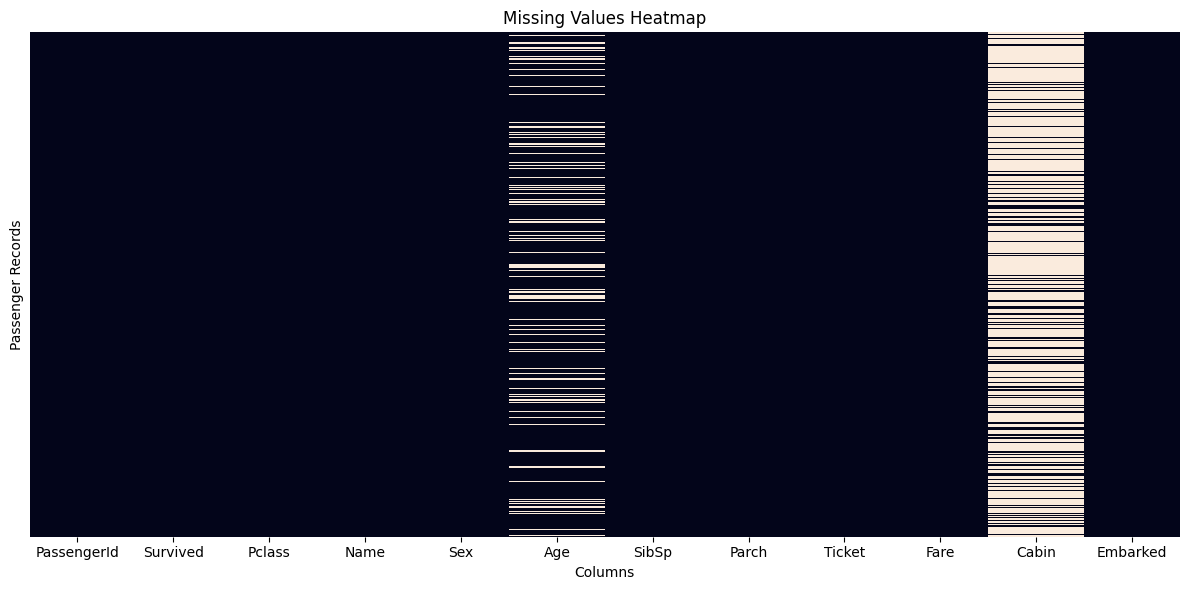

In [41]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Passenger Records")

plt.tight_layout()
plt.show()

# Missing Values Bar Chart

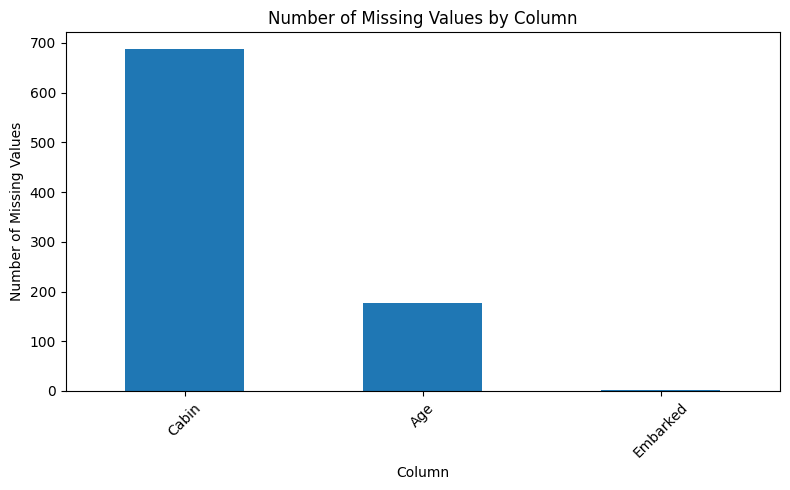

In [42]:
missing_count = df.isnull().sum()

missing_count = missing_count[
    missing_count > 0
].sort_values(ascending=False)

plt.figure(figsize=(8, 5))

missing_count.plot(
    kind="bar"
)

plt.title("Number of Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Missing Percentage Bar Chart

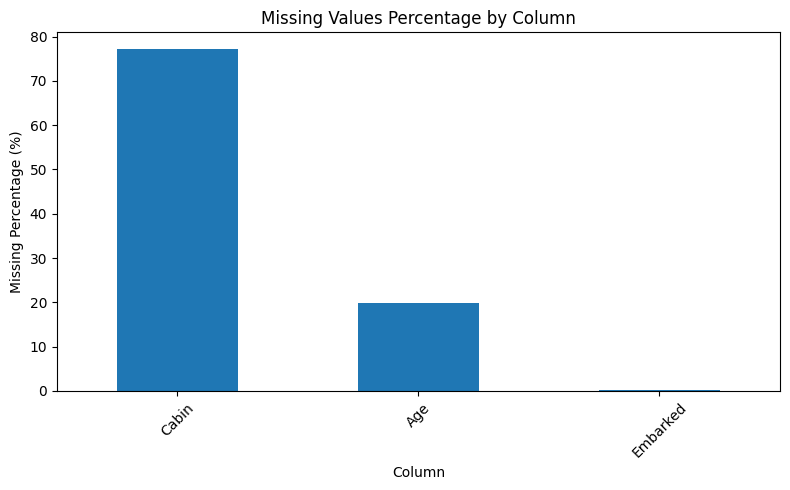

In [43]:
missing_pct = (
    df.isnull().mean() * 100
)

missing_pct = missing_pct[
    missing_pct > 0
].sort_values(ascending=False)

plt.figure(figsize=(8, 5))

missing_pct.plot(
    kind="bar"
)

plt.title("Missing Values Percentage by Column")
plt.xlabel("Column")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Missing vs Non-Missing Values

In [44]:
missing_comparison = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Available": df.notnull().sum()
})

missing_comparison

,Missing,Available
PassengerId,0,891
Survived,0,891
Pclass,0,891
Name,0,891
Sex,0,891
Age,177,714
SibSp,0,891
Parch,0,891
Ticket,0,891
Fare,0,891


# Visualize Missing vs Available Values

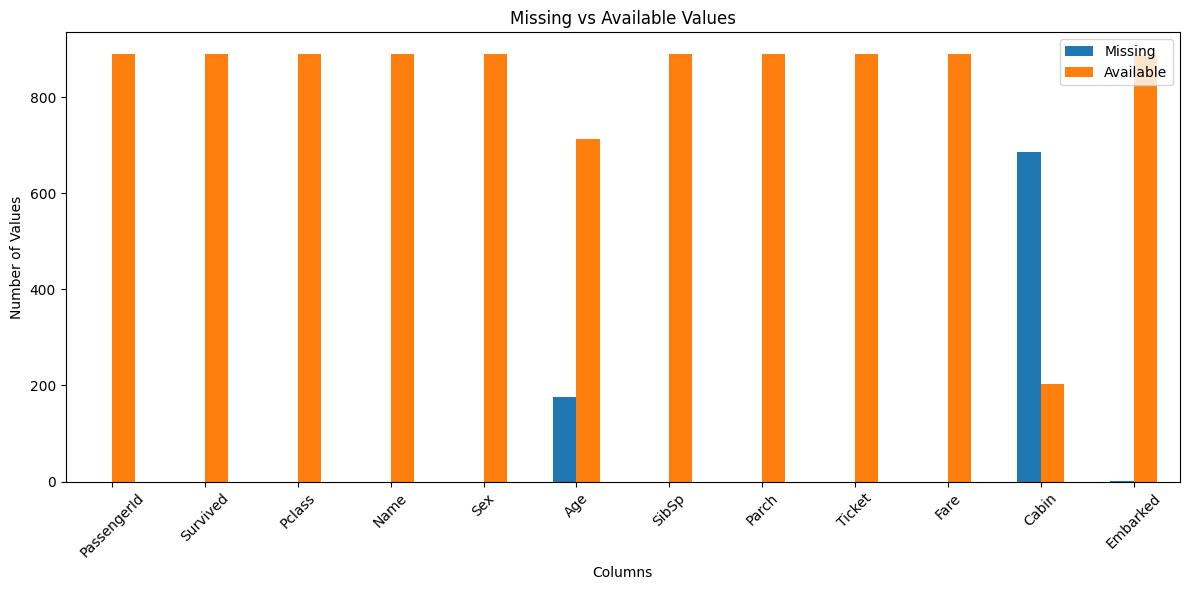

In [45]:
missing_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Missing vs Available Values")
plt.xlabel("Columns")
plt.ylabel("Number of Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Missing Data Report

In [46]:
missing_report = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Total Values": len(df),
    "Missing Values": df.isnull().sum().values,
    "Available Values": df.notnull().sum().values,
    "Missing %": (
        df.isnull().sum().values / len(df) * 100
    ).round(2)
})

missing_report

,Column,Data Type,Total Values,Missing Values,Available Values,Missing %
0,PassengerId,int64,891,0,891,0.00
1,Survived,int64,891,0,891,0.00
2,Pclass,int64,891,0,891,0.00
3,Name,object,891,0,891,0.00
4,Sex,object,891,0,891,0.00
5,Age,float64,891,177,714,19.87
6,SibSp,int64,891,0,891,0.00
7,Parch,int64,891,0,891,0.00
8,Ticket,object,891,0,891,0.00
9,Fare,float64,891,0,891,0.00


# Categorize Missing Data Severity

In [47]:
def missing_category(value):
    if value == 0:
        return "No Missing Values"
    elif value < 5:
        return "Very Low"
    elif value <= 20:
        return "Moderate"
    elif value <= 50:
        return "High"
    else:
        return "Very High"

missing_report["Missing Category"] = (
    missing_report["Missing %"]
    .apply(missing_category)
)

missing_report

,Column,Data Type,Total Values,Missing Values,Available Values,Missing %,Missing Category
0,PassengerId,int64,891,0,891,0.00,No Missing Values
1,Survived,int64,891,0,891,0.00,No Missing Values
2,Pclass,int64,891,0,891,0.00,No Missing Values
3,Name,object,891,0,891,0.00,No Missing Values
4,Sex,object,891,0,891,0.00,No Missing Values
5,Age,float64,891,177,714,19.87,Moderate
6,SibSp,int64,891,0,891,0.00,No Missing Values
7,Parch,int64,891,0,891,0.00,No Missing Values
8,Ticket,object,891,0,891,0.00,No Missing Values
9,Fare,float64,891,0,891,0.00,No Missing Values


# Check Duplicate Rows Separately

In [48]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [49]:
# Example only — do not run automatically
# df["Age"] = df["Age"].fillna(df["Age"].median())

In [52]:
# Example only
df["Cabin_Missing"] = df["Cabin"].isnull().astype(int)


In [53]:
df[df["Embarked"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Missing
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN,0
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN,0


# Final Missing-Value Summary

In [54]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Total Cells",
        "Total Missing Cells",
        "Overall Missing Percentage",
        "Columns With Missing Values",
        "Columns Without Missing Values",
        "Rows With Missing Values"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.size,
        df.isnull().sum().sum(),
        round(df.isnull().sum().sum() / df.size * 100, 2),
        df.isnull().any().sum(),
        (~df.isnull().any()).sum(),
        df.isnull().any(axis=1).sum()
    ]
})

final_summary

,Metric,Value
0,Total Rows,891.00
1,Total Columns,13.00
2,Total Cells,11583.00
3,Total Missing Cells,866.00
4,Overall Missing Percentage,7.48
5,Columns With Missing Values,3.00
6,Columns Without Missing Values,10.00
7,Rows With Missing Values,708.00


# Check duplicates

In [55]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Total Duplicate Rows:", duplicate_count)

Total Duplicate Rows: 0


In [56]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (891, 13)


In [57]:
print(df.isnull().sum())

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age              177
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            687
Embarked           2
Cabin_Missing      0
dtype: int64


In [58]:
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

print("Missing Age after filling:", df["Age"].isnull().sum())

Missing Age after filling: 0


In [59]:
# Find most common Embarked value
embarked_mode = df["Embarked"].mode()[0]

print("Embarked Mode:", embarked_mode)

# Fill missing values
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

print("Missing Embarked after filling:", df["Embarked"].isnull().sum())

Embarked Mode: S
Missing Embarked after filling: 0


# Fill missing Embarked

In [60]:
# Find most common Embarked value
embarked_mode = df["Embarked"].mode()[0]

print("Embarked Mode:", embarked_mode)

# Fill missing values
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

print("Missing Embarked after filling:", df["Embarked"].isnull().sum())

Embarked Mode: S
Missing Embarked after filling: 0


# Handle missing Cabin

In [61]:
df["Cabin"] = df["Cabin"].fillna("Unknown")

print("Missing Cabin after filling:", df["Cabin"].isnull().sum())

Missing Cabin after filling: 0


# Check all missing values after cleaning

In [62]:
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin            0
Embarked         0
Cabin_Missing    0
dtype: int64


# Check duplicate values again

In [63]:
print("Duplicate Rows After Cleaning:", df.duplicated().sum())

Duplicate Rows After Cleaning: 0


# Conclusion

The Titanic dataset was successfully cleaned by identifying and handling missing values and duplicate records. Missing `Age` values were replaced with the median age, missing `Embarked` values were filled using the most frequent value, and missing `Cabin` values were labeled as `Unknown` because a large proportion of cabin information was unavailable. Duplicate records were identified and removed to improve data quality. After cleaning, the dataset contains no missing values and no duplicate rows. The cleaned dataset is now more consistent and suitable for further exploratory data analysis and visualization.
